In [2]:
!!pip install librosa

['Collecting librosa',
 '  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)',
 'Collecting audioread>=2.1.9 (from librosa)',
 '  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)',
 'Requirement already satisfied: numba>=0.51.0 in /opt/homebrew/anaconda3/lib/python3.13/site-packages (from librosa) (0.61.0)',
 'Requirement already satisfied: numpy>=1.22.3 in /opt/homebrew/anaconda3/lib/python3.13/site-packages (from librosa) (1.26.4)',
 'Requirement already satisfied: scipy>=1.6.0 in /opt/homebrew/anaconda3/lib/python3.13/site-packages (from librosa) (1.15.3)',
 'Requirement already satisfied: scikit-learn>=1.1.0 in /opt/homebrew/anaconda3/lib/python3.13/site-packages (from librosa) (1.6.1)',
 'Requirement already satisfied: joblib>=1.0 in /opt/homebrew/anaconda3/lib/python3.13/site-packages (from librosa) (1.4.2)',
 'Requirement already satisfied: decorator>=4.3.0 in /opt/homebrew/anaconda3/lib/python3.13/site-packages (from librosa) (5.1.1)',
 'Collecting s

In [3]:
import sys
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Add the src directory to system path so we can import our modules
sys.path.append(os.path.abspath(os.path.join('..')))

from src.preprocessing import AudioPreprocessor
from src.features import LogMelFeatureExtractor

# Configuration
SR = 16000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

Running on: cpu


# Cell 2: Data Discovery (Handling Your New Folders)
## This cell scans your directory and assigns a Label ID to each folder name (e.g., dog_0 -> 0, coughs_24 -> 1).

Found 52 classes:
['airplane_47', 'bonfire_12', 'breathing_23', 'brushing_teeth_27', 'can_opening_34', 'carhorn_43', 'cat_5', 'chainsaw_41', 'chirping_birds_14', 'church_bells_46'] ...
Total Audio Files: 7213


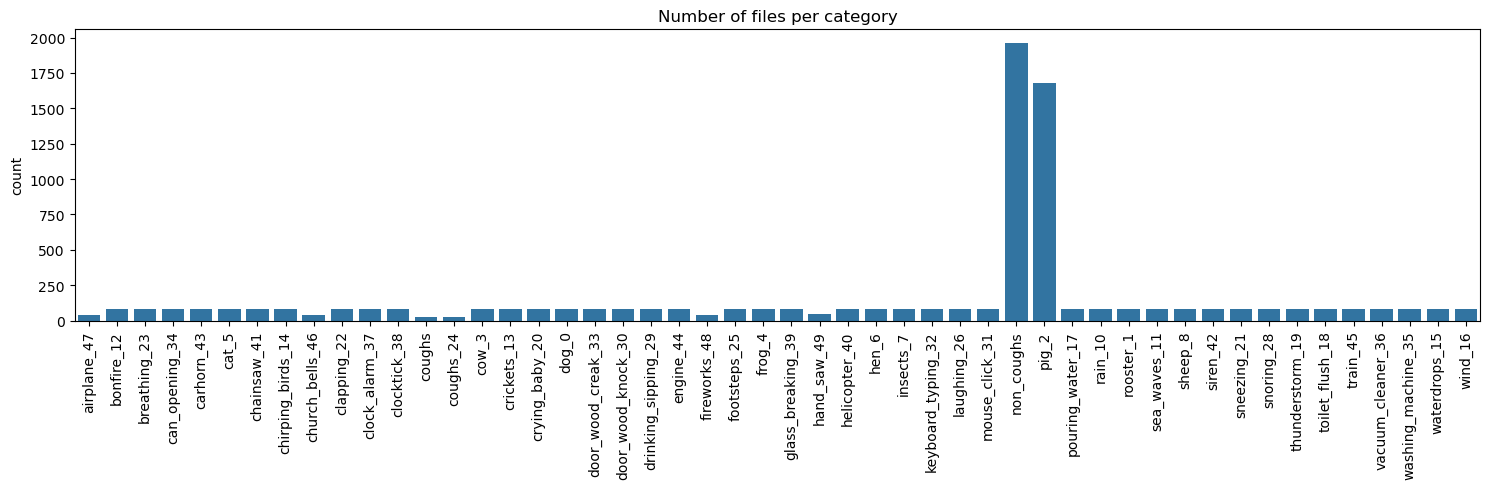

In [4]:
data_dir = '../data'

# Get all subfolders (classes) avoiding hidden files like .DS_Store
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')]
classes.sort() # Ensure consistent order

class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

print(f"Found {len(classes)} classes:")
print(classes[:10], "...") # Print first 10

# Collect all files
all_files = []
all_labels = []

for cls_name in classes:
    cls_folder = os.path.join(data_dir, cls_name)
    files = glob.glob(os.path.join(cls_folder, "*.wav"))
    all_files.extend(files)
    all_labels.extend([class_to_idx[cls_name]] * len(files))

print(f"Total Audio Files: {len(all_files)}")

# Visualize Class Balance
plt.figure(figsize=(15, 5))
sns.countplot(x=[idx_to_class[i] for i in all_labels])
plt.xticks(rotation=90)
plt.title("Number of files per category")
plt.tight_layout()
plt.show()

# Cell 3: Spectrogram Visualization
## Let's visually compare "Coughing" vs "Sneezing" vs "Dog" to see if they look different.

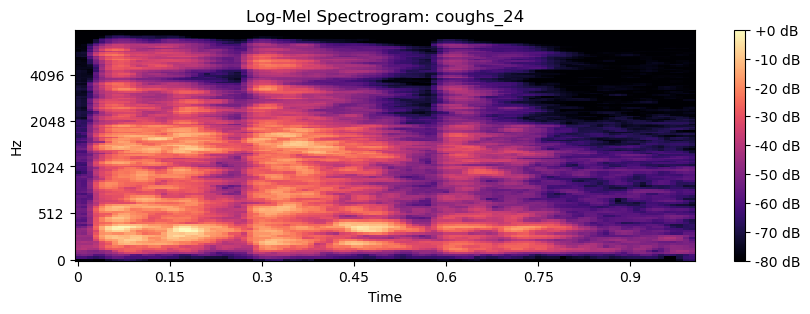

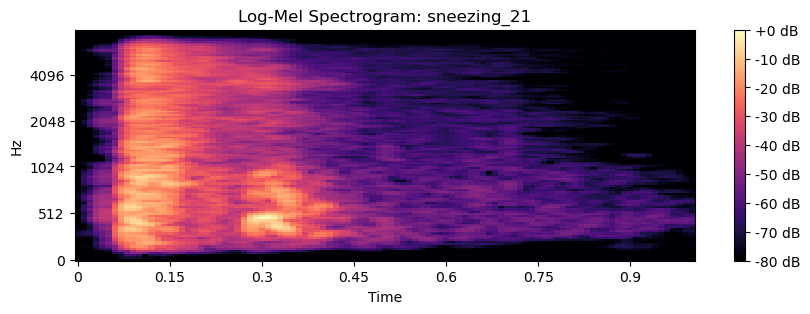

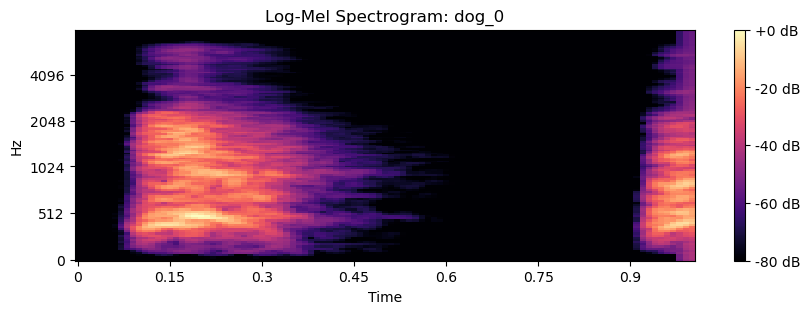

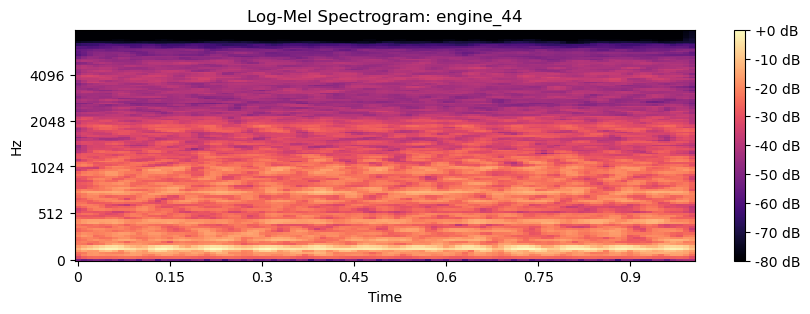

In [5]:
def plot_spec(cls_name):
    # Find a random file for this class
    cls_idx = class_to_idx.get(cls_name)
    if cls_idx is None:
        print(f"Class {cls_name} not found.")
        return
        
    matching_files = [f for f, l in zip(all_files, all_labels) if l == cls_idx]
    if not matching_files:
        return
        
    file_path = matching_files[0]
    
    # Load and Preprocess
    y, _ = librosa.load(file_path, sr=SR, duration=1.0)
    pre = AudioPreprocessor(sr=SR)
    y_clean = pre.process(y)
    
    # Features
    feat = LogMelFeatureExtractor(sr=SR)
    spec = feat.compute(y_clean)[0] # Remove channel dim
    
    plt.figure(figsize=(10, 3))
    librosa.display.specshow(spec, sr=SR, x_axis='time', y_axis='mel', hop_length=160)
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Log-Mel Spectrogram: {cls_name}")
    plt.show()

# Try plotting specific relevant classes if they exist
targets = ['coughs_24', 'sneezing_21', 'dog_0', 'engine_44']
for t in targets:
    if t in classes:
        plot_spec(t)

# Cell 4: Define Multi-Class Model
## Since your src/model.py was built for binary classification (1 output), we define a new model here with num_classes outputs.

In [6]:
class MultiClassCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Layer 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        # CHANGE: Output layer size = num_classes
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x) # Return raw logits (no sigmoid)

# Cell 5: Create Dataset & DataLoader

In [7]:
class EnvSoundDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        self.preprocessor = AudioPreprocessor(sr=SR)
        self.featurizer = LogMelFeatureExtractor(sr=SR)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        
        # Load 1 second
        y, _ = librosa.load(path, sr=SR, duration=1.0)
        
        # Pad or Truncate
        if len(y) < SR:
            y = np.pad(y, (0, SR - len(y)))
        elif len(y) > SR:
            y = y[:SR]
            
        y = self.preprocessor.process(y)
        spec = self.featurizer.compute(y)
        
        return torch.tensor(spec, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# Split Data
X_train, X_val, y_train, y_val = train_test_split(all_files, all_labels, test_size=0.2, random_state=42)

train_ds = EnvSoundDataset(X_train, y_train)
val_ds = EnvSoundDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# Cell 6: Train the Model
## We use CrossEntropyLoss because this is now a multi-class problem (not binary).

In [8]:
model = MultiClassCNN(num_classes=len(classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 15
train_losses = []
val_accuracies = []

print("Starting training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    val_accuracies.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.2f}%")

# Save the trained multi-class model
os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/multiclass_cnn.pth')
print("Model saved to ../models/multiclass_cnn.pth")

Starting training...
Epoch 1/15 | Loss: 2.8291 | Val Acc: 26.61%
Epoch 2/15 | Loss: 2.5797 | Val Acc: 24.74%
Epoch 3/15 | Loss: 2.4694 | Val Acc: 23.28%
Epoch 4/15 | Loss: 2.4001 | Val Acc: 22.73%
Epoch 5/15 | Loss: 2.3276 | Val Acc: 27.93%
Epoch 6/15 | Loss: 2.2423 | Val Acc: 23.84%
Epoch 7/15 | Loss: 2.1933 | Val Acc: 28.07%
Epoch 8/15 | Loss: 2.1544 | Val Acc: 27.51%
Epoch 9/15 | Loss: 2.1107 | Val Acc: 25.09%
Epoch 10/15 | Loss: 2.0839 | Val Acc: 26.75%
Epoch 11/15 | Loss: 2.0523 | Val Acc: 27.30%
Epoch 12/15 | Loss: 2.0204 | Val Acc: 23.98%
Epoch 13/15 | Loss: 1.9907 | Val Acc: 24.53%
Epoch 14/15 | Loss: 1.9589 | Val Acc: 28.62%
Epoch 15/15 | Loss: 1.9384 | Val Acc: 24.05%
Model saved to ../models/multiclass_cnn.pth


# Cell 7: Test Inference (Try it on a file)

In [9]:
def predict_sound(file_path):
    model.eval()
    # Load & Prep
    y, _ = librosa.load(file_path, sr=SR, duration=1.0)
    if len(y) < SR: y = np.pad(y, (0, SR - len(y)))
    else: y = y[:SR]
    
    pre = AudioPreprocessor(sr=SR)
    y = pre.process(y)
    
    feat = LogMelFeatureExtractor(sr=SR)
    spec = feat.compute(y)
    
    # Inference
    inp = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(inp)
        probs = torch.softmax(logits, 1)
        score, idx = torch.max(probs, 1)
        
    print(f"File: {os.path.basename(file_path)}")
    print(f"Prediction: {idx_to_class[idx.item()]} ({score.item()*100:.1f}%)")

# Test on a validation file
test_file = X_val[0]
predict_sound(test_file)

File: 4-176638-A-43 2.wav
Prediction: train_45 (31.8%)


###  Important Notes on Your Data
###  Duplicates: I see you have a coughs folder AND a coughs_24 folder. If they contain the same files, the model might get confused (it will see the same data with two ### different labels). Recommendation: Delete the generic coughs and non_coughs folders and stick to the specific ESC-50 folders (coughs_24, sneezing_21, etc.) for cleaner training.

### Classes: This notebook will treat every folder in data/ as a distinct category. Ensure there are no empty folders.